# E-Commerce Sales Performance Analysis (Olist)
This notebook contains the complete Exploratory Data Analysis (EDA) on the Brazilian E-Commerce Public Dataset by Olist.


## Data Loading


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_dir = r"F:\Datasets and ML\datasets\Brazilian E-Commerce Public Dataset by Olist"


In [2]:
customers = pd.read_csv(os.path.join(data_dir, "olist_customers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(data_dir, "olist_geolocation_dataset.csv"))
order_items = pd.read_csv(os.path.join(data_dir, "olist_order_items_dataset.csv"))
order_payments = pd.read_csv(os.path.join(data_dir, "olist_order_payments_dataset.csv"))
order_reviews = pd.read_csv(os.path.join(data_dir, "olist_order_reviews_dataset.csv"))
orders = pd.read_csv(os.path.join(data_dir, "olist_orders_dataset.csv"))
products = pd.read_csv(os.path.join(data_dir, "olist_products_dataset.csv"))
sellers = pd.read_csv(os.path.join(data_dir, "olist_sellers_dataset.csv"))
translation = pd.read_csv(os.path.join(data_dir, "product_category_name_translation.csv"))


In [3]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "translation": translation
}
for name, df in datasets.items():
    print(f"{name}: shape {df.shape}")


customers: shape (99441, 5)
geolocation: shape (1000163, 5)
order_items: shape (112650, 7)
order_payments: shape (103886, 5)
order_reviews: shape (99224, 7)
orders: shape (99441, 8)
products: shape (32951, 9)
sellers: shape (3095, 4)
translation: shape (71, 2)


## Master Data Merge (Q12)


In [4]:
geo_agg = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()


In [5]:
m_df = orders.copy()
m_df = pd.merge(m_df, order_items, on='order_id', how='left')
m_df = pd.merge(m_df, products, on='product_id', how='left')
m_df = pd.merge(m_df, translation, on='product_category_name', how='left')
m_df = pd.merge(m_df, customers, on='customer_id', how='left')
m_df = pd.merge(m_df, order_payments, on='order_id', how='left')
m_df = pd.merge(m_df, order_reviews, on='order_id', how='left')
m_df = pd.merge(m_df, sellers, on='seller_id', how='left')
m_df = pd.merge(m_df, geo_agg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')


In [6]:
m_df.shape


(119143, 45)

## Data Cleaning (Q11)


In [7]:
m_df.isnull().sum()


order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853
product_width_cm                    853
product_category_name_english      2567
customer_unique_id                    0
customer_zip_code_prefix              0


In [8]:
m_df.duplicated().sum()


np.int64(0)

In [9]:
df_cleaned = m_df.drop_duplicates()


In [10]:
date_cols = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date', 'shipping_limit_date', 
    'review_creation_date', 'review_answer_timestamp'
]
for col in date_cols:
    df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')


In [11]:
num_cols = ['price', 'freight_value', 'payment_value']
for col in num_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')


In [12]:
df_cleaned = df_cleaned[~((df_cleaned['price'] < 0) | (df_cleaned['freight_value'] < 0) | (df_cleaned['payment_value'] < 0))]


In [13]:
df_cleaned.shape


(119143, 45)

## Q1: Product Category Revenue


In [14]:
df_cleaned['product_category_name_english'] = df_cleaned['product_category_name_english'].fillna(df_cleaned['product_category_name'].fillna('unknown'))
df_cleaned['total_item_revenue'] = df_cleaned['price'] + df_cleaned['freight_value']
cat_revenue = df_cleaned.groupby('product_category_name_english')['total_item_revenue'].sum().reset_index()
cat_revenue = cat_revenue.sort_values(by='total_item_revenue', ascending=False)
cat_revenue.head(15)


,product_category_name_english,total_item_revenue
43,health_beauty,1491397.76
73,watches_gifts,1358845.59
7,bed_bath_table,1327662.02
67,sports_leisure,1205197.85
15,computers_accessories,1104362.03
39,furniture_decor,955367.22
49,housewares,823623.50
20,cool_stuff,752702.21
5,auto,714431.95
42,garden_tools,625387.31


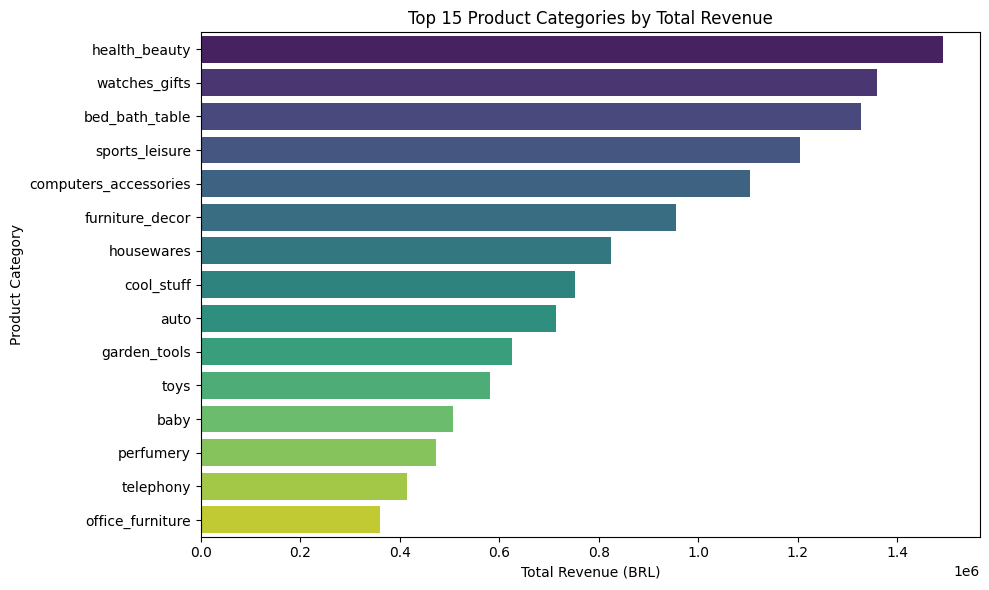

In [15]:
plt.figure(figsize=(10, 6))
top_15_cat = cat_revenue.head(15)
sns.barplot(data=top_15_cat, x='total_item_revenue', y='product_category_name_english', palette='viridis', hue='product_category_name_english', legend=False)
plt.title('Top 15 Product Categories by Total Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


> [!NOTE]
> Health & Beauty, Watch/Gifts, and Bed/Bath/Table are the top revenue-producing product categories. Higher-value categories contribute the most, showing where marketing budgets can be most effective.


## Q2: Regional Sales


In [16]:
city_sales = df_cleaned.groupby(['customer_city', 'customer_state'])['price'].sum().reset_index(name='revenue').sort_values(by='revenue', ascending=False)
state_sales = df_cleaned.groupby('customer_state')['price'].sum().reset_index(name='revenue').sort_values(by='revenue', ascending=False)


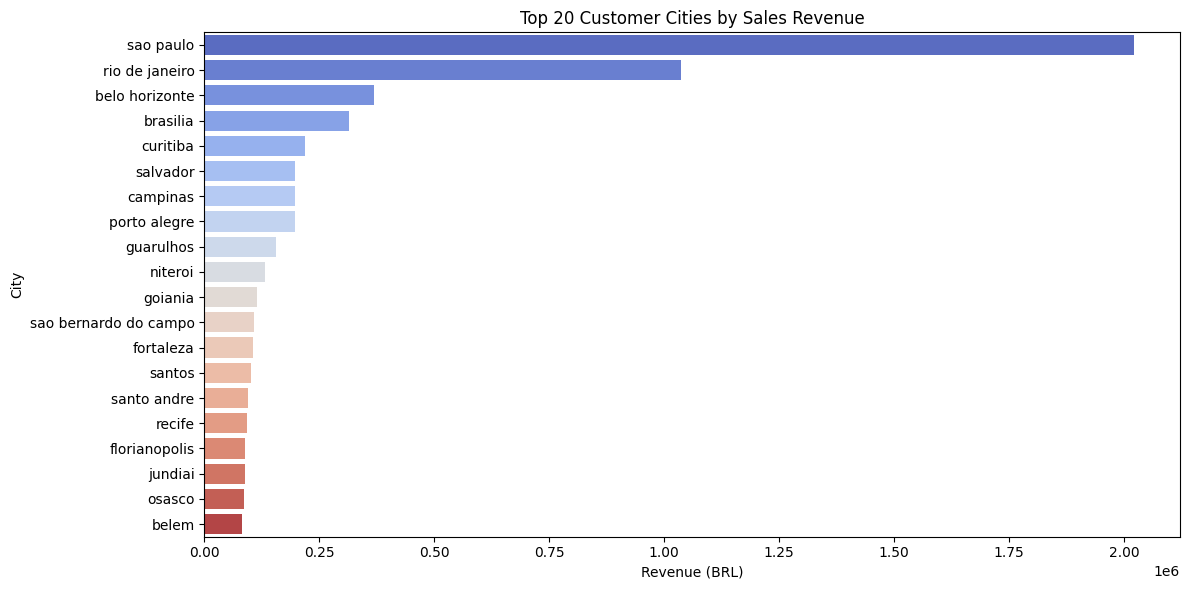

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(data=city_sales.head(20), x='revenue', y='customer_city', palette='coolwarm', hue='customer_city', legend=False)
plt.title('Top 20 Customer Cities by Sales Revenue')
plt.xlabel('Revenue (BRL)')
plt.ylabel('City')
plt.tight_layout()
plt.show()


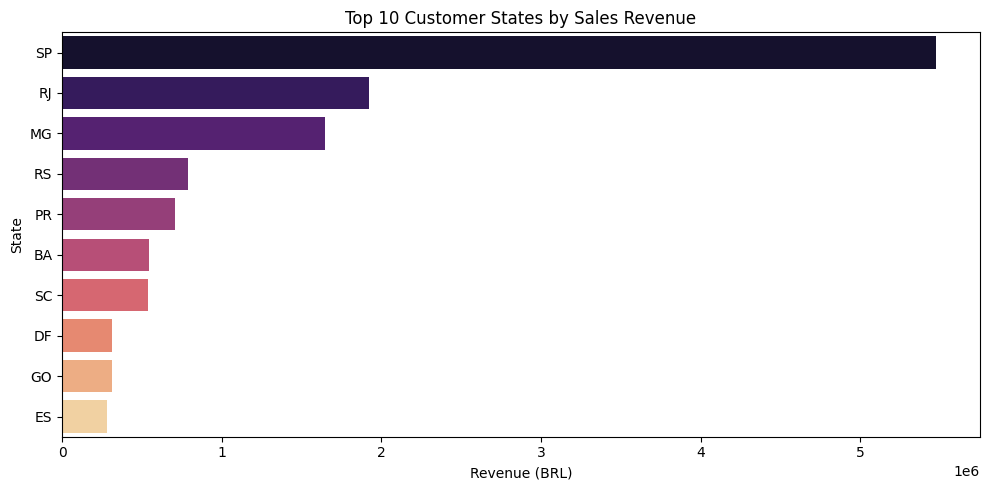

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=state_sales.head(10), x='revenue', y='customer_state', palette='magma', hue='customer_state', legend=False)
plt.title('Top 10 Customer States by Sales Revenue')
plt.xlabel('Revenue (BRL)')
plt.ylabel('State')
plt.tight_layout()
plt.show()


> [!NOTE]
> Sales are highly concentrated in the state of Sao Paulo (SP) and Rio de Janeiro (RJ), with Sao Paulo city dominating the revenue generation. E-commerce logistics and marketing should remain focused on this highly active South-Eastern region.


## Q3: Customer Segmentation by Spend


In [19]:
cust_spend = df_cleaned.groupby('customer_unique_id').agg({
    'price': 'sum',
    'order_id': 'nunique',
    'review_score': 'mean'
}).reset_index().rename(columns={'price': 'total_spend', 'order_id': 'order_count'})

q10 = cust_spend['total_spend'].quantile(0.90)
q30 = cust_spend['total_spend'].quantile(0.70)
q60 = cust_spend['total_spend'].quantile(0.40)

def segment_cust(spend):
    if spend >= q10: return 'High Value'
    elif spend >= q30: return 'Mid-High'
    elif spend >= q60: return 'Mid-Low'
    else: return 'Low Value'

cust_spend['segment'] = cust_spend['total_spend'].apply(segment_cust)
segment_table = cust_spend.groupby('segment').agg({
    'customer_unique_id': 'count',
    'total_spend': 'mean',
    'order_count': 'mean',
    'review_score': 'mean'
}).reset_index().rename(columns={
    'customer_unique_id': 'customer_count',
    'total_spend': 'avg_spend',
    'order_count': 'avg_orders_per_customer',
    'review_score': 'avg_review_score'
})
segment_order = ['High Value', 'Mid-High', 'Mid-Low', 'Low Value']
segment_table['segment'] = pd.Categorical(segment_table['segment'], categories=segment_order, ordered=True)
segment_table = segment_table.sort_values('segment').reset_index(drop=True)
segment_table


,segment,customer_count,avg_spend,avg_orders_per_customer,avg_review_score
0,High Value,9613,631.848629,1.115365,3.968917
1,Mid-High,19223,195.324822,1.062425,4.039702
2,Mid-Low,29350,101.242496,1.024974,4.110359
3,Low Value,37910,38.869492,1.007993,4.116915


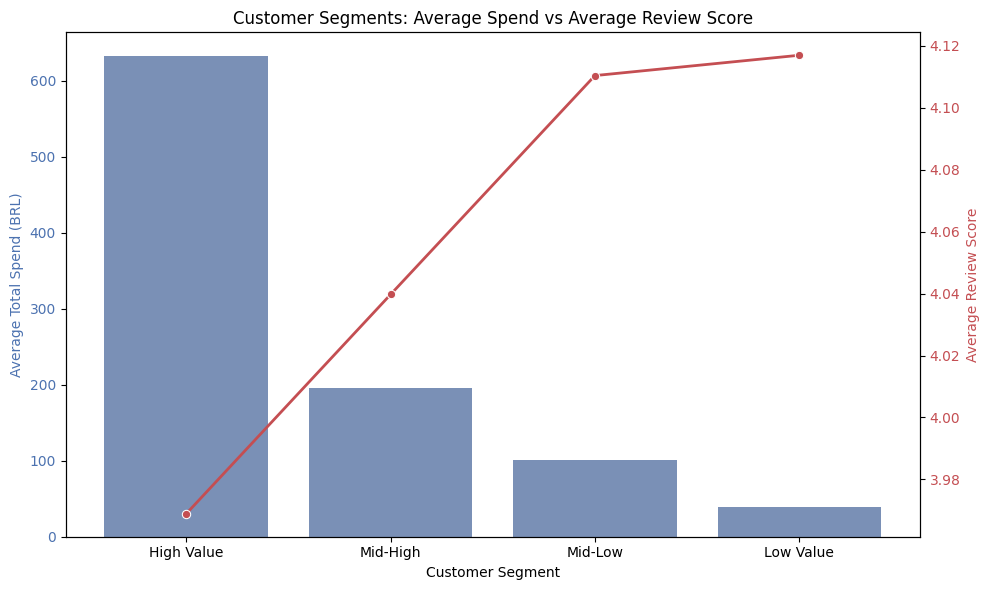

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 6))
color = '#4c72b0'
ax1.set_xlabel('Customer Segment')
ax1.set_ylabel('Average Total Spend (BRL)', color=color)
sns.barplot(data=segment_table, x='segment', y='avg_spend', color=color, ax=ax1, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#c44e52'
ax2.set_ylabel('Average Review Score', color=color)
sns.lineplot(data=segment_table, x='segment', y='avg_review_score', color=color, ax=ax2, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Customer Segments: Average Spend vs Average Review Score')
fig.tight_layout()
plt.show()


> [!NOTE]
> High Value customers represent the top 10% of spenders but show relatively similar average review scores compared to other groups, suggesting that high spending is driven by larger or more expensive orders rather than higher satisfaction.


## Q4: Purchasing Behavior


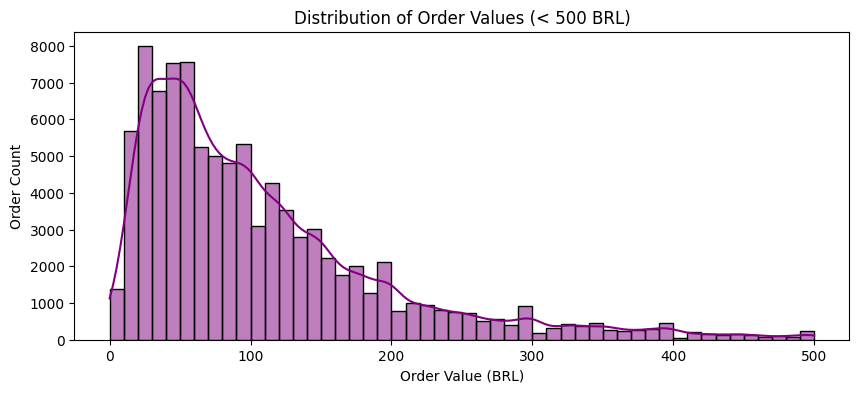

In [21]:
order_vals = df_cleaned.groupby('order_id')['price'].sum().reset_index()
plt.figure(figsize=(10, 4))
sns.histplot(order_vals[order_vals['price'] < 500]['price'], bins=50, kde=True, color='purple')
plt.title('Distribution of Order Values (< 500 BRL)')
plt.xlabel('Order Value (BRL)')
plt.ylabel('Order Count')
plt.show()


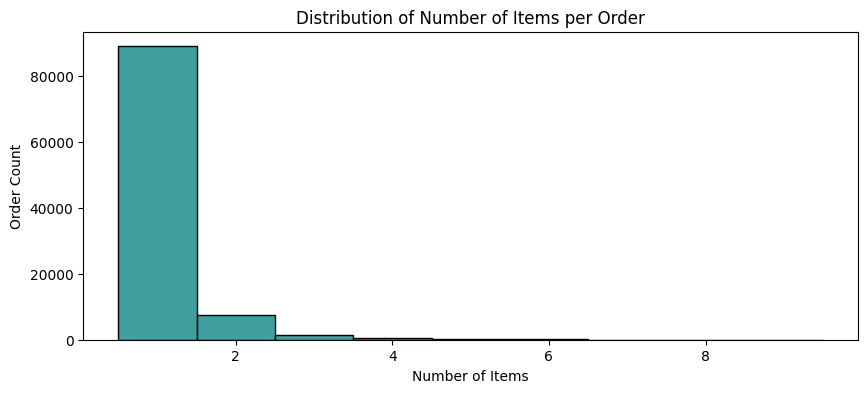

In [22]:
items_per_order = df_cleaned.groupby('order_id')['order_item_id'].max().reset_index()
plt.figure(figsize=(10, 4))
sns.histplot(items_per_order[items_per_order['order_item_id'] < 10]['order_item_id'], bins=10, color='teal', discrete=True)
plt.title('Distribution of Number of Items per Order')
plt.xlabel('Number of Items')
plt.ylabel('Order Count')
plt.show()


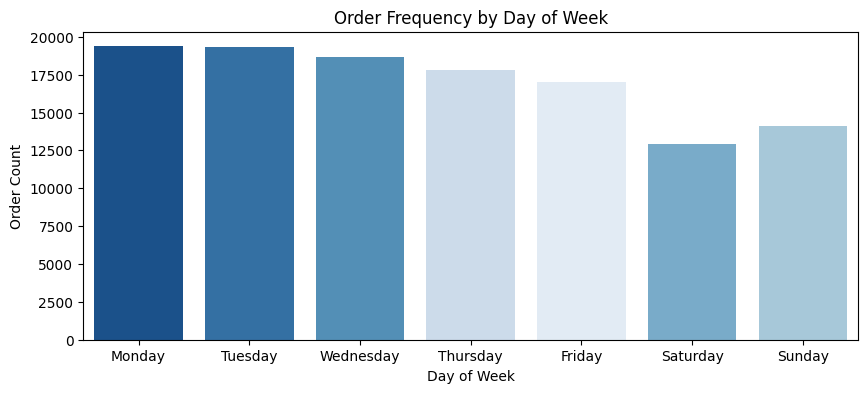

In [23]:
df_cleaned['order_purchase_day'] = df_cleaned['order_purchase_timestamp'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 4))
sns.countplot(data=df_cleaned, x='order_purchase_day', order=day_order, palette='Blues_r', hue='order_purchase_day', legend=False)
plt.title('Order Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Order Count')
plt.show()


In [24]:
delivery_times = (df_cleaned['order_delivered_customer_date'] - df_cleaned['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
delivery_times.mean()


np.float64(12.488070798723728)

> [!NOTE]
> Most orders consist of only 1 item and have a value under 150 BRL. Order activity is slightly higher during the start and middle of the week, and the average delivery time takes about 12.5 days.


## Q5: Top Performing Products


In [25]:
prod_vol = df_cleaned.groupby('product_id').size().reset_index(name='units_sold')
prod_rev = df_cleaned.groupby('product_id')['price'].sum().reset_index(name='revenue')
prod_ranking = pd.merge(prod_vol, prod_rev, on='product_id').sort_values(by='revenue', ascending=False)
prod_ranking.head(10)


,product_id,units_sold,revenue
24086,bb50f2e236e5eea0100680137654686c,210,68810.00
27613,d6160fb7873f184099d9bc95e30376af,41,56948.83
14068,6cdd53843498f92890544667809f1595,159,55779.90
27039,d1c427060a0f73f6b889a5c7c61f2ac4,357,49141.40
19742,99a4788cb24856965c36a24e339b6058,528,46575.66
4996,25c38557cf793876c5abdd5931f922db,44,44829.32
8051,3dd2a17168ec895c781a9191c1e95ad7,278,41682.20
22112,aca2eb7d00ea1a7b8ebd4e68314663af,536,38248.20
10867,53b36df67ebb7c41585e8d54d6772e08,327,38158.21
12351,5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90


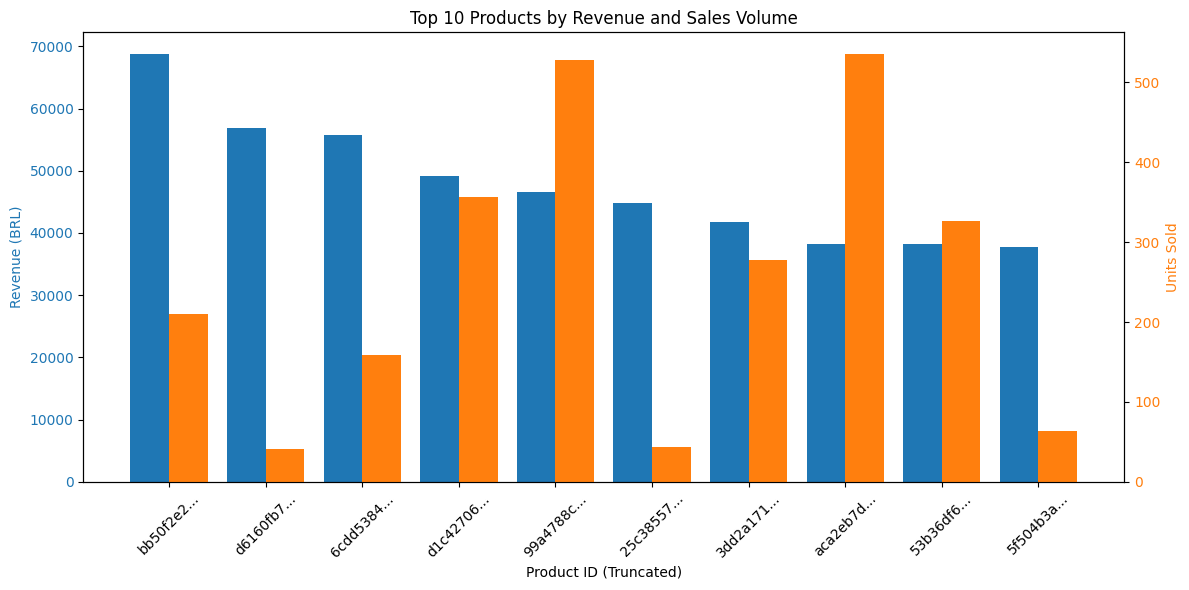

In [26]:
top_10_prod = prod_ranking.head(10)
fig, ax1 = plt.subplots(figsize=(12, 6))
color = '#1f77b4'
ax1.set_xlabel('Product ID (Truncated)')
ax1.set_ylabel('Revenue (BRL)', color=color)
bars1 = ax1.bar(np.arange(10) - 0.2, top_10_prod['revenue'], width=0.4, color=color, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(10))
ax1.set_xticklabels([pid[:8] + '...' for pid in top_10_prod['product_id']], rotation=45)

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Units Sold', color=color)
bars2 = ax2.bar(np.arange(10) + 0.2, top_10_prod['units_sold'], width=0.4, color=color, label='Units Sold')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Top 10 Products by Revenue and Sales Volume')
fig.tight_layout()
plt.show()


> [!NOTE]
> Top revenue contributors are not necessarily the ones with the highest unit volume, representing higher-priced item types. Standardizing product pricing or bundled options could optimize margins.


## Q6: Payment Methods


In [27]:
payment_summary = df_cleaned.groupby('payment_type').agg({
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index().rename(columns={'order_id': 'transaction_count', 'payment_value': 'total_revenue'}).sort_values(by='total_revenue', ascending=False)
payment_summary


,payment_type,transaction_count,total_revenue
1,credit_card,87776,15775450.54
0,boleto,23190,4110920.74
4,voucher,6465,435917.84
2,debit_card,1706,257374.89
3,not_defined,3,0.00


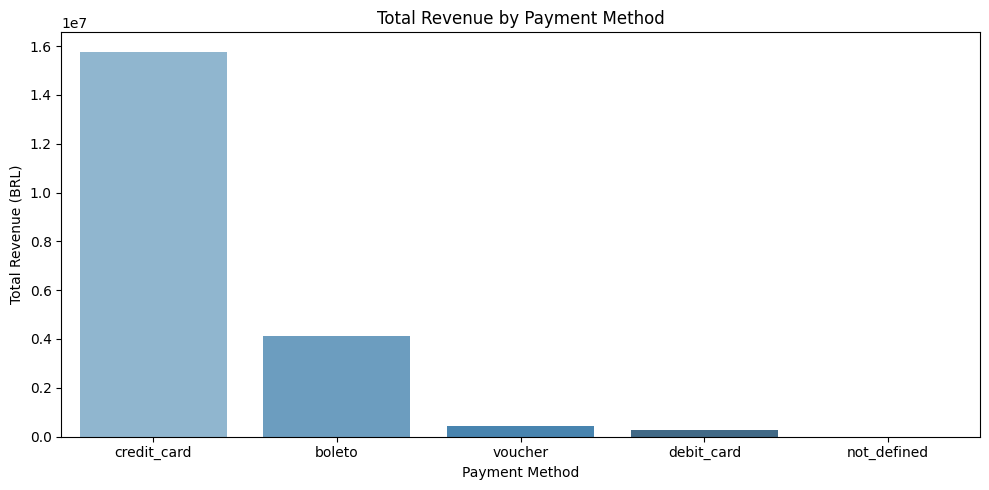

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(data=payment_summary, x='payment_type', y='total_revenue', palette='Blues_d', hue='payment_type', legend=False)
plt.title('Total Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.show()


> [!NOTE]
> Credit cards dominate transaction value and count. Encouraging methods with lower processing fees (like Boleto or instant payments) could improve net margins.


## Q7: Top Sellers


In [29]:
seller_rev = df_cleaned.groupby('seller_id')['price'].sum().reset_index(name='total_revenue')
seller_rev = seller_rev.sort_values(by='total_revenue', ascending=False)
seller_rev.head(15)


,seller_id,total_revenue
1013,53243585a1d6dc2643021fd1853d8905,244627.55
857,4869f7a5dfa277a7dca6462dcf3b52b2,237867.23
881,4a3ca9315b744ce9f8e9374361493884,215825.77
3024,fa1c13f2614d7b5c4749cbc52fecda94,203984.22
1535,7c67e1448b00f6e969d365cea6b010ab,199688.11
1560,7e93a43ef30c4f03f38b393420bc753a,182878.17
2643,da8622b14eb17ae2831f4ac5b9dab84a,171784.57
1505,7a67c85e85bb2ce8582c35f2203ad736,150749.79
192,1025f0e2d44d7041d6cf58b6550e0bfa,143675.53
1824,955fee9216a65b617aa5c0531780ce60,137405.00


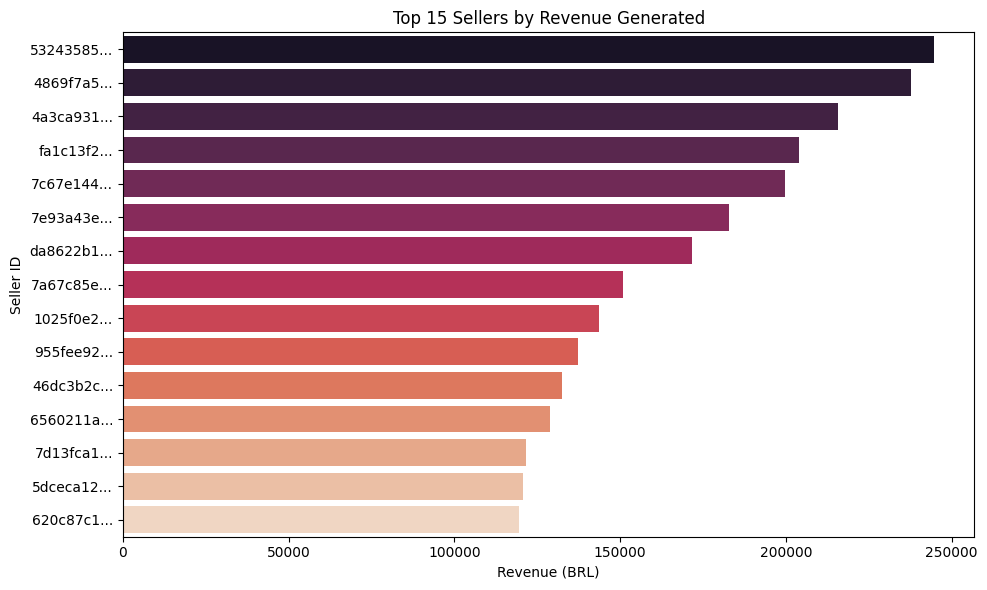

In [30]:
plt.figure(figsize=(10, 6))
top_15_sellers = seller_rev.head(15)
sns.barplot(data=top_15_sellers, x='total_revenue', y='seller_id', palette='rocket', orient='h', hue='seller_id', legend=False)
plt.title('Top 15 Sellers by Revenue Generated')
plt.xlabel('Revenue (BRL)')
plt.ylabel('Seller ID')
plt.yticks(range(15), [sid[:8] + '...' for sid in top_15_sellers['seller_id']])
plt.tight_layout()
plt.show()


> [!NOTE]
> Top 15 sellers account for a major share of e-commerce transactions. Retaining these key merchants and offering them seller-focused services is key.


## Q8: Review Scores Analysis


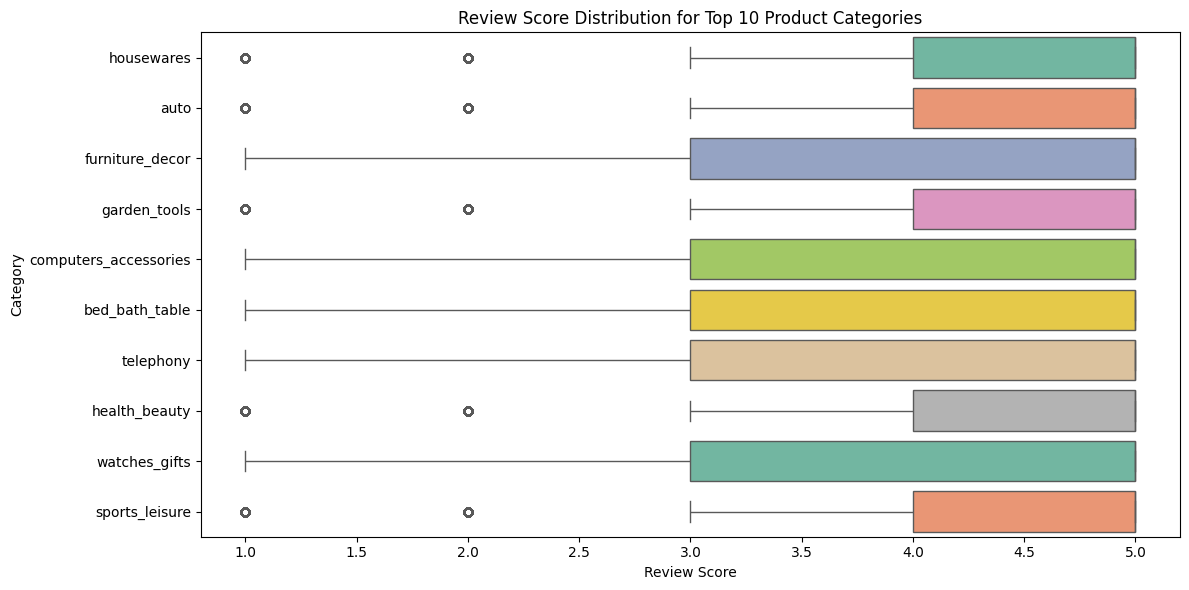

In [31]:
top_10_cats_names = df_cleaned['product_category_name_english'].value_counts().head(10).index
df_top_cats = df_cleaned[df_cleaned['product_category_name_english'].isin(top_10_cats_names)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_cats, x='review_score', y='product_category_name_english', palette='Set2', hue='product_category_name_english', legend=False)
plt.title('Review Score Distribution for Top 10 Product Categories')
plt.xlabel('Review Score')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


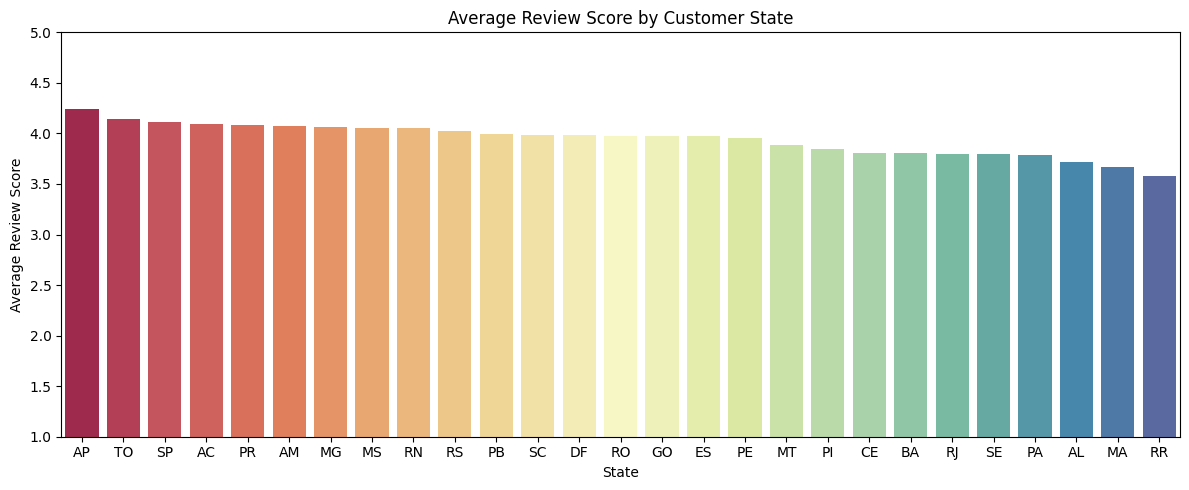

In [32]:
avg_review_state = df_cleaned.groupby('customer_state')['review_score'].mean().reset_index(name='avg_review_score').sort_values(by='avg_review_score', ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(data=avg_review_state, x='customer_state', y='avg_review_score', palette='Spectral', hue='customer_state', legend=False)
plt.title('Average Review Score by Customer State')
plt.xlabel('State')
plt.ylabel('Average Review Score')
plt.ylim(1, 5)
plt.tight_layout()
plt.show()


> [!NOTE]
> Across all top product categories and states, review scores consistently center around 4 or 5 stars. However, there are a significant number of 1-star outliers, indicating occasional service breakdowns.


## Q9: Sales Trends Over Time


In [33]:
df_cleaned['order_month'] = df_cleaned['order_purchase_timestamp'].dt.to_period('M')
monthly_trends = df_cleaned.groupby('order_month').agg({
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index().rename(columns={'order_id': 'order_count', 'price': 'revenue'})
monthly_trends['order_month_str'] = monthly_trends['order_month'].astype(str)
monthly_trends_filtered = monthly_trends[(monthly_trends['order_month_str'] >= '2017-01') & (monthly_trends['order_month_str'] <= '2018-08')]


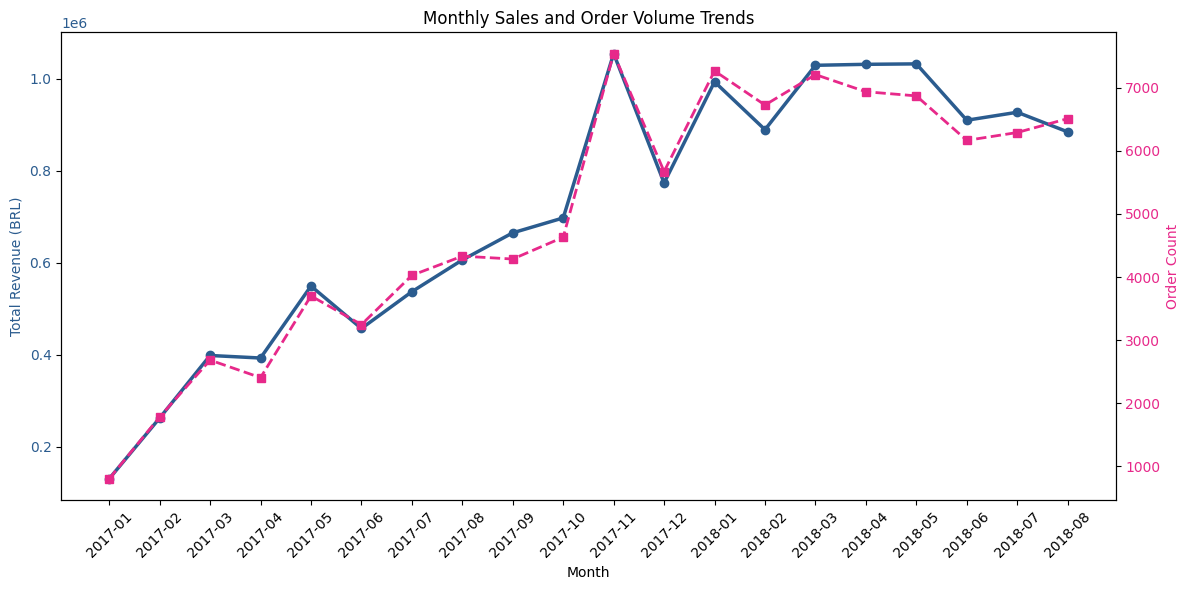

In [34]:
fig, ax1 = plt.subplots(figsize=(12, 6))
color = '#2b5c8f'
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue (BRL)', color=color)
ax1.plot(monthly_trends_filtered['order_month_str'], monthly_trends_filtered['revenue'], color=color, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(len(monthly_trends_filtered)))
ax1.set_xticklabels(monthly_trends_filtered['order_month_str'], rotation=45)

ax2 = ax1.twinx()
color = '#e7298a'
ax2.set_ylabel('Order Count', color=color)
ax2.plot(monthly_trends_filtered['order_month_str'], monthly_trends_filtered['order_count'], color=color, marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Sales and Order Volume Trends')
fig.tight_layout()
plt.show()


> [!NOTE]
> Revenue and order volumes show strong growth starting in early 2017 and plateauing mid-2018, with a prominent spike in November (corresponding to Black Friday promotions).


## Q10: Customer Retention (One-time vs Repeat Spenders)


In [35]:
repeat_analysis = cust_spend.groupby('order_count').size().reset_index(name='customer_count')
repeat_analysis['customer_type'] = repeat_analysis['order_count'].apply(lambda x: 'Repeat' if x > 1 else 'One-time')
type_summary = repeat_analysis.groupby('customer_type')['customer_count'].sum().reset_index()
type_summary


,customer_type,customer_count
0,One-time,93099
1,Repeat,2997


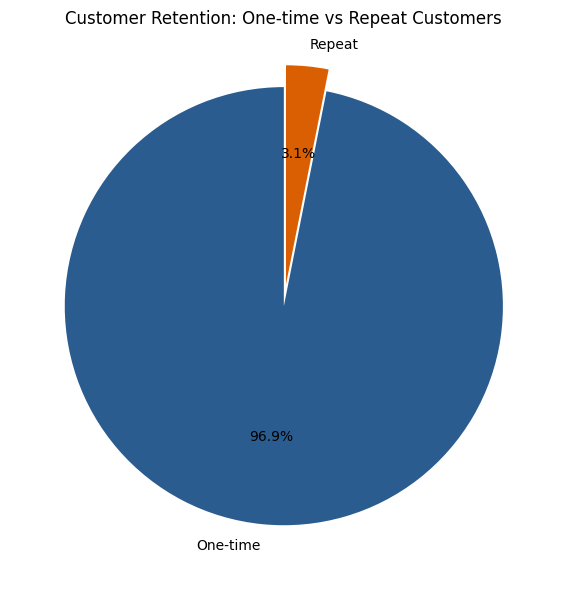

In [36]:
plt.figure(figsize=(6, 6))
plt.pie(type_summary['customer_count'], labels=type_summary['customer_type'], autopct='%1.1f%%', colors=['#2b5c8f', '#d95f02'], startangle=90, explode=(0, 0.1))
plt.title('Customer Retention: One-time vs Repeat Customers')
plt.tight_layout()
plt.show()


> [!NOTE]
> Repeat customers represent only a tiny fraction (around 3%) of the customer base. Designing loyalty programs and remarketing campaigns could significantly boost customer retention.
